# 02 — What determines how people use AI?

For each of 3,259 occupational tasks, the Anthropic Economic Index tells us how humans actually collaborate with Claude. Some tasks are overwhelmingly **directive** — the human tells the AI what to do and accepts the output. Others are **iterative** — the human stays in the loop, revising and validating.

What separates these two modes of use? The conventional assumption is skill level: routine, low-education tasks get automated first. The data says otherwise.

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.data import build_task_feature_matrix

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 150

In [2]:
tasks = build_task_feature_matrix()
tu = tasks.drop_duplicates(subset='task_name').reset_index(drop=True)

# Keep tasks with enough conversations for stable estimates
tu = tu[tu['conversation_count'] >= 20].reset_index(drop=True)
print(f'{len(tu):,} tasks with >= 20 conversations')

2,819 tasks with >= 20 conversations


## Education does not predict automation

The most common narrative about AI and work is that low-skill, routine tasks will be automated first. If this were true, we would see a negative relationship between education requirements and automation share.

We don't.

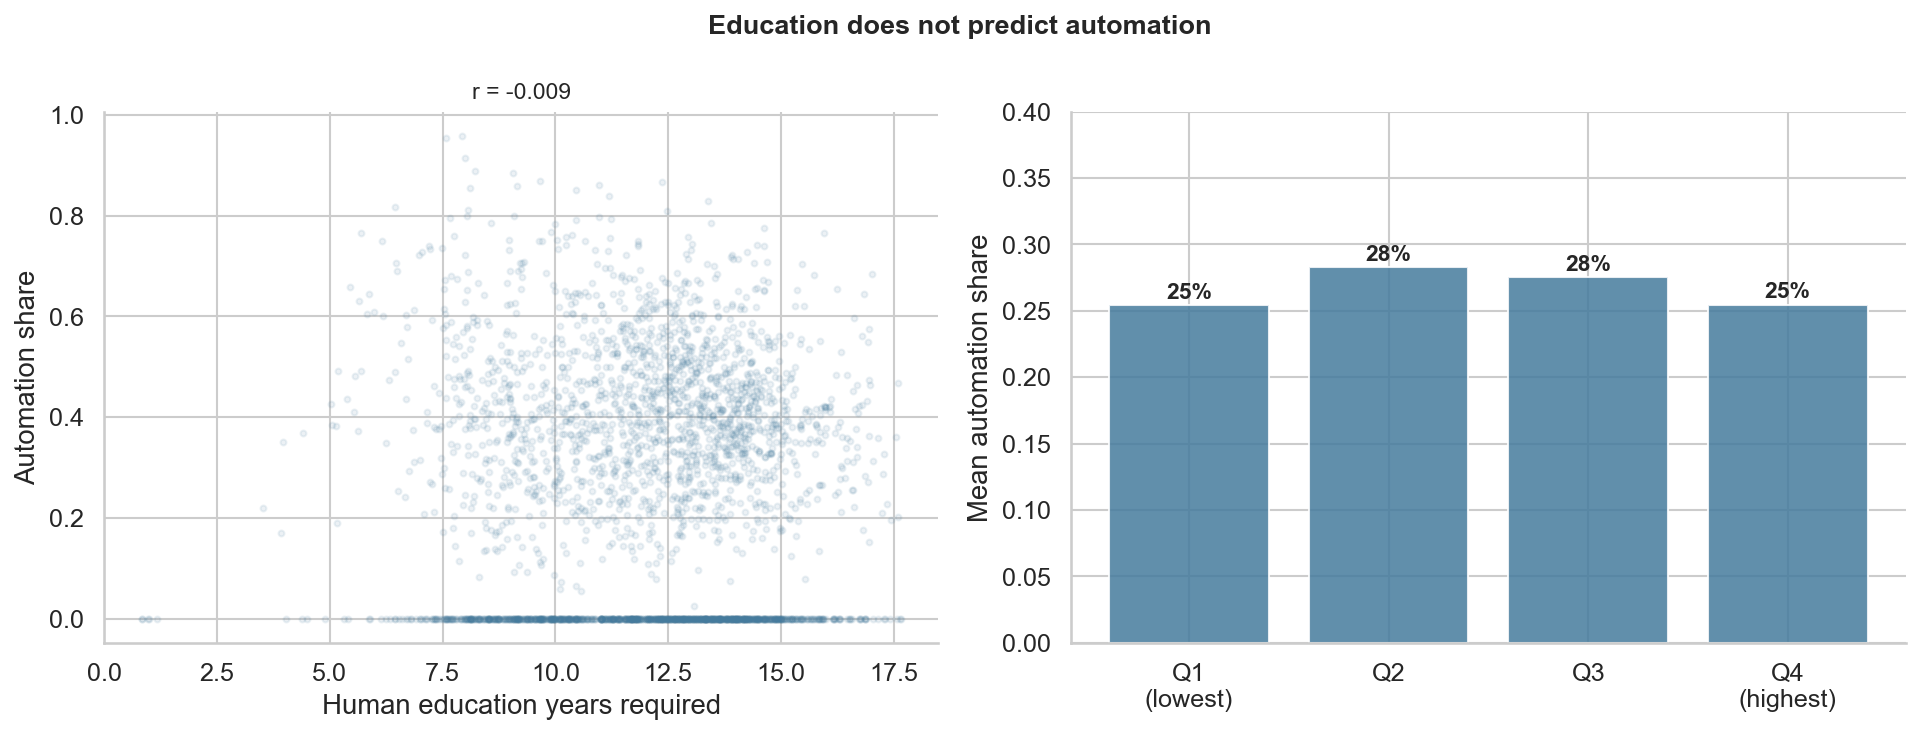

In [3]:
r, p = stats.pearsonr(tu['human_education_years'], tu['automation_share'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(tu['human_education_years'], tu['automation_share'],
           alpha=0.1, s=8, color='#457B9D')
ax.set_xlabel('Human education years required')
ax.set_ylabel('Automation share')
ax.set_title(f'r = {r:.3f}', fontsize=11)

ax = axes[1]
q = pd.qcut(tu['human_education_years'], 4, labels=['Q1\n(lowest)', 'Q2', 'Q3', 'Q4\n(highest)'])
means = tu.groupby(q)['automation_share'].mean()
ax.bar(range(4), means.values, color='#457B9D', alpha=0.85, edgecolor='white')
ax.set_xticks(range(4))
ax.set_xticklabels(means.index)
ax.set_ylabel('Mean automation share')
for i, v in enumerate(means.values):
    ax.text(i, v + 0.005, f'{v:.0%}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylim(0, 0.4)

plt.suptitle('Education does not predict automation', fontsize=13, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig('../figures/02_education_vs_automation.png', bbox_inches='tight')
plt.show()

## What does predict it: the nature of the output

Instead of education level, we can classify tasks by what they *produce*. A simple heuristic: the first verb of the O\*NET task description. Tasks that start with *write*, *prepare*, *create* produce artifacts. Tasks that start with *advise*, *counsel*, *teach* require human interaction.

This crude classification explains variation that education cannot.

In [4]:
# Classify by output type
tu['first_verb'] = tu['task_name'].str.lower().str.split().str[0]

artifact_verbs = ['write', 'prepare', 'draft', 'create', 'compile', 'compose',
                  'generate', 'produce', 'calculate', 'compute', 'transcribe',
                  'record', 'convert', 'enter', 'tabulate', 'process']
interaction_verbs = ['advise', 'counsel', 'teach', 'explain', 'confer', 'consult',
                     'negotiate', 'interview', 'communicate', 'collaborate',
                     'educate', 'mentor', 'present']

def classify(verb):
    if verb in artifact_verbs:
        return 'Produces artifacts'
    elif verb in interaction_verbs:
        return 'Requires interaction'
    return None

tu['output_type'] = tu['first_verb'].map(classify)
classified = tu.dropna(subset=['output_type'])

art = classified[classified['output_type'] == 'Produces artifacts']
int_ = classified[classified['output_type'] == 'Requires interaction']

print(f'Artifact tasks:     {len(art):>4}  mean automation = {art["automation_share"].mean():.0%}')
print(f'Interaction tasks:  {len(int_):>4}  mean automation = {int_["automation_share"].mean():.0%}')
print(f'Difference:                              {art["automation_share"].mean() - int_["automation_share"].mean():+.0%}')

# Statistical test
t_stat, t_p = stats.ttest_ind(art['automation_share'], int_['automation_share'])
print(f'\nWelch t-test: t = {t_stat:.1f}, p = {t_p:.1e}')

Artifact tasks:      435  mean automation = 35%
Interaction tasks:   302  mean automation = 17%
Difference:                              +18%

Welch t-test: t = 11.1, p = 1.1e-26


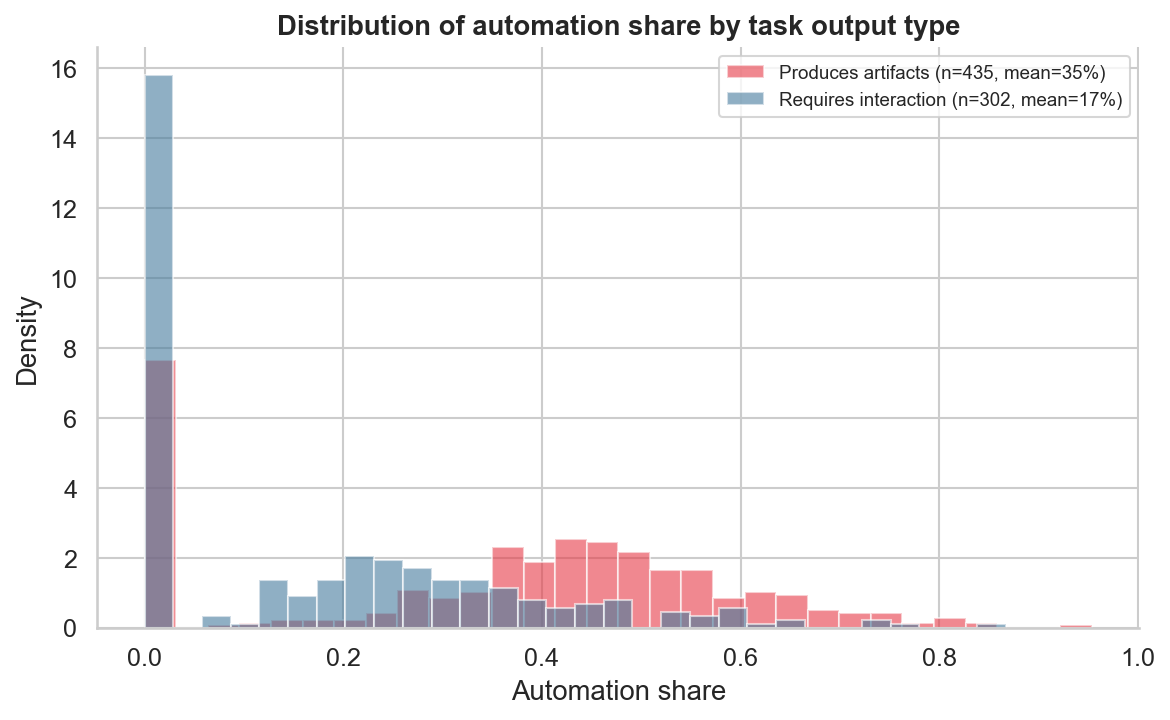

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

for label, data, color in [('Produces artifacts', art, '#E63946'),
                            ('Requires interaction', int_, '#457B9D')]:
    ax.hist(data['automation_share'], bins=30, alpha=0.6, color=color,
            label=f'{label} (n={len(data)}, mean={data["automation_share"].mean():.0%})',
            density=True, edgecolor='white')

ax.set_xlabel('Automation share')
ax.set_ylabel('Density')
ax.set_title('Distribution of automation share by task output type', fontweight='bold')
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig('../figures/03_output_type_distributions.png', bbox_inches='tight')
plt.show()

## Concrete examples

The pattern is intuitive once you see specific tasks.

In [6]:
high_vol = tu[tu['conversation_count'] >= 50]

print('Most automated tasks (>= 50 conversations):')
for _, r in high_vol.nlargest(8, 'automation_share').iterrows():
    print(f'  {r["automation_share"]:>3.0%}  {r["task_name"][:80]}')

print()
print('Least automated tasks:')
for _, r in high_vol[high_vol['automation_share'] == 0].sample(8, random_state=42).iterrows():
    print(f'  {r["automation_share"]:>3.0%}  {r["task_name"][:80]}')

Most automated tasks (>= 50 conversations):
  96%  maintain knowledge of relevant national and international current events.
  95%  prepare and deliver news, sports, or weather reports, gathering and rewriting ma
  91%  report on specialized fields such as medicine, green technology, environmental i
  89%  provide information about community health and social resources.
  89%  read trade journals and professional literature to stay informed on trends, inno
  86%  perform needs assessments or consult with clients to determine the types of rese
  86%  transcribe recorded proceedings in accordance with established formats.
  86%  take dictation using shorthand, a stenotype machine, or headsets and transcribin

Least automated tasks:
   0%  provide technical assistance to installers, technicians, or other solar professi
   0%  conduct social research.
   0%  instruct and counsel patients about prescribed therapeutic regimens, normal grow
   0%  plan and conduct research to develop and test

The automated tasks produce information artifacts: news reports, transcriptions, storyboards, data conversions. The augmented tasks are interpersonal: advising, counseling, communicating, collaborating.

## Expanding the taxonomy

We can be more granular about task types. Eight categories, still based on the leading verb:

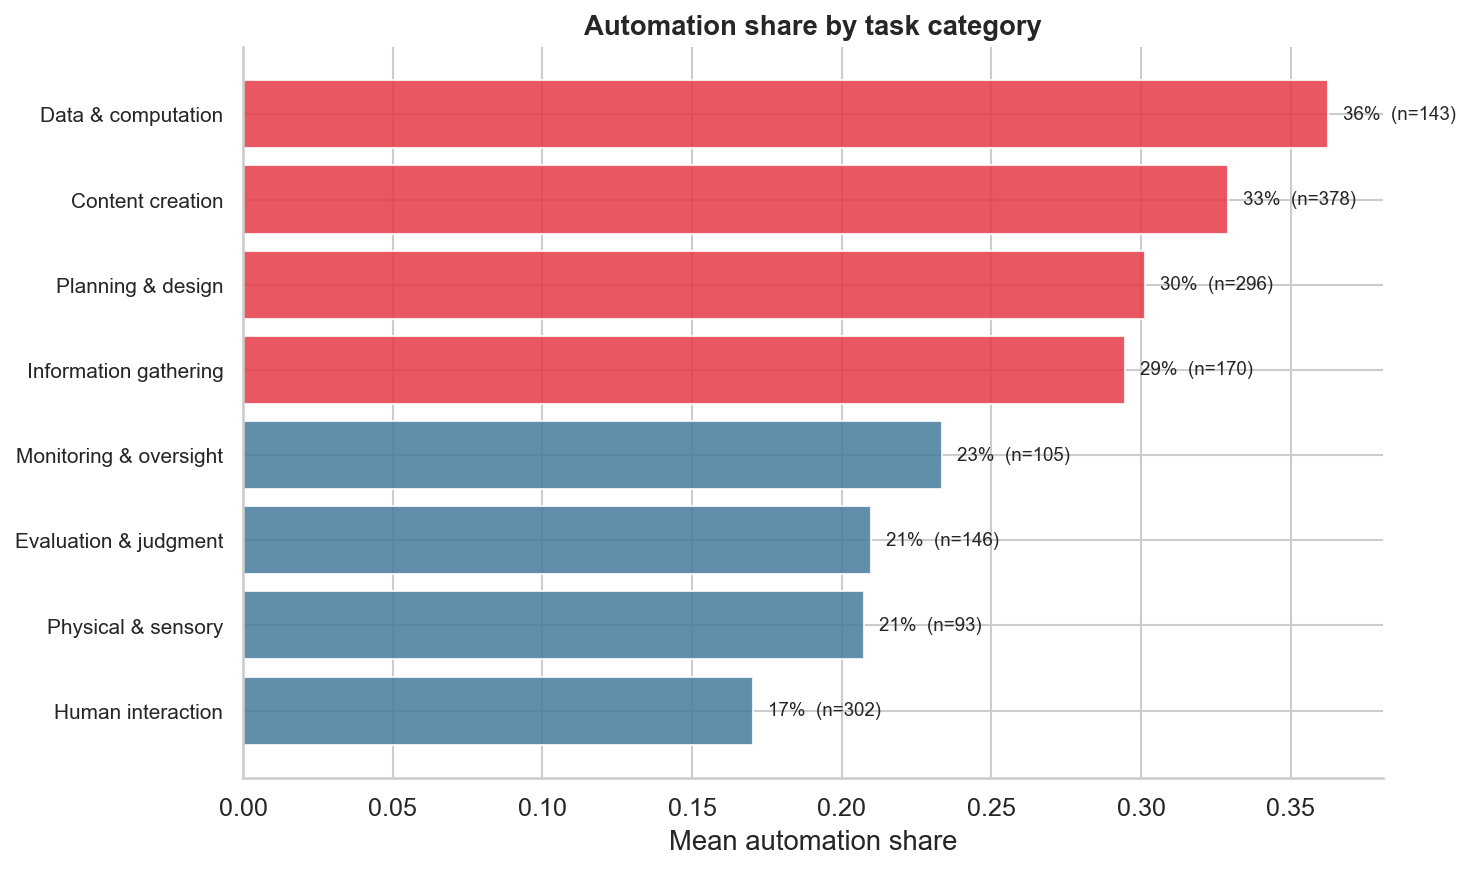

In [7]:
full_categories = {
    'Content creation': ['write', 'prepare', 'draft', 'create', 'compile', 'compose', 'generate', 'produce'],
    'Data & computation': ['calculate', 'compute', 'transcribe', 'record', 'convert', 'enter', 'tabulate', 'process', 'analyze'],
    'Planning & design': ['plan', 'design', 'develop', 'organize', 'coordinate', 'schedule', 'arrange'],
    'Information gathering': ['read', 'research', 'gather', 'collect', 'review', 'search', 'find'],
    'Monitoring & oversight': ['monitor', 'supervise', 'oversee', 'track', 'check', 'verify', 'ensure', 'maintain'],
    'Evaluation & judgment': ['evaluate', 'assess', 'determine', 'select', 'recommend', 'judge', 'decide'],
    'Physical & sensory': ['inspect', 'examine', 'observe', 'test', 'measure', 'operate', 'install', 'repair'],
    'Human interaction': ['advise', 'counsel', 'teach', 'explain', 'confer', 'consult', 'negotiate',
                          'interview', 'communicate', 'collaborate', 'educate', 'mentor', 'present'],
}

for cat, verbs in full_categories.items():
    tu.loc[tu['first_verb'].isin(verbs), 'category'] = cat

cat_df = tu.dropna(subset=['category'])
cat_stats = cat_df.groupby('category').agg(
    automation=('automation_share', 'mean'),
    n=('task_name', 'count'),
).sort_values('automation')

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#E63946' if v > cat_stats['automation'].median() else '#457B9D'
          for v in cat_stats['automation']]
ax.barh(range(len(cat_stats)), cat_stats['automation'], color=colors,
        alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(cat_stats)))
ax.set_yticklabels(cat_stats.index, fontsize=10)
ax.set_xlabel('Mean automation share')

for i, (_, row) in enumerate(cat_stats.iterrows()):
    ax.text(row['automation'] + 0.005, i, f"{row['automation']:.0%}  (n={row['n']:.0f})",
            va='center', fontsize=9)

ax.set_title('Automation share by task category', fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig('../figures/04_task_categories.png', bbox_inches='tight')
plt.show()

Content creation and data processing cluster at the top. Human interaction and evaluation at the bottom. The gradient follows output type, not complexity.

## Controlling for education

To confirm education isn't a confound, we can check: within artifact-producing tasks, do high-education tasks automate less? No.

In [8]:
for label, subset in [('Artifact tasks', art), ('Interaction tasks', int_)]:
    r, p = stats.pearsonr(subset['human_education_years'], subset['automation_share'])
    print(f'{label:25s}  education-automation r = {r:+.3f}  (p = {p:.2f}, n = {len(subset)})')

Artifact tasks             education-automation r = -0.168  (p = 0.00, n = 435)
Interaction tasks          education-automation r = -0.024  (p = 0.68, n = 302)
